## **Regression**

**What is Regression?**

Regression is a statistical method that helps us to understand and predict the relationship between variable. It desribes how one variable changes `(dependent variable)` as another variable changes `(independent variable)`.

There are two major kind of regression : `linear-regression` and `logistic-regression`

**So without wasting anymore time let's dive into code!**

> Here we are going to use a new python module named `scikit-learn` to impelement linear regression

In [ ]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# imports
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [23]:
X,y = datasets.make_regression(n_samples=100,n_features=1,noise=20,random_state=4)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1234)

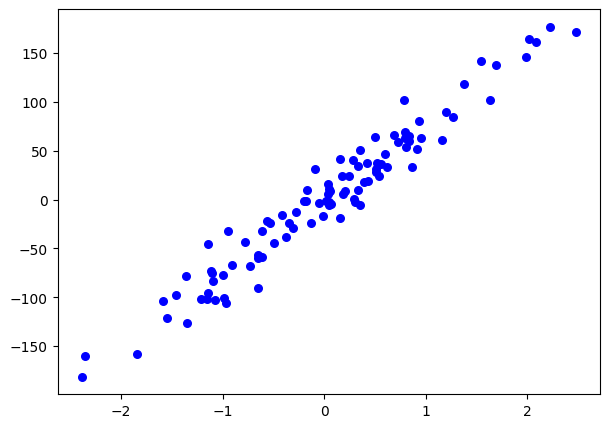

In [41]:
fig = plt.figure(figsize=(7,5))
plt.scatter(X[:,0],y,color='b',marker='o',s=30)
plt.show()

In [25]:
print('X train : ',X_train.shape)
print('y train : ',y_train.shape)

X train :  (80, 1)
y train :  (80,)


In [26]:
class LINEAR_REGRESSION:
    
    def __init__(self,learning_rate=0.001,n_iters=1000):
        self.learning_rate=learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        
    def fit(self,X,y):
        n_samples,n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_iters):
            y_predicted = np.dot(X,self.weights) + self.bias
            dw = (1/n_samples) * np.dot(X.T,(y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    
    def predict(self,X):
        y_predicted = np.dot(X,self.weights) + self.bias
        return y_predicted

In [33]:
regressor = LINEAR_REGRESSION(learning_rate=0.01)
regressor.fit(X_train,y_train)
predicted = regressor.predict(X_test)

In [34]:
# to get accuracy
def mse(y_true,y_predicted):
    return np.mean((y_true-y_predicted)**2)

In [35]:
mse_value = mse(y_test,predicted)

In [36]:
print('Mean Square Value = ',mse_value)

Mean Square Value =  305.7719958301902


> let's see what it did!

In [37]:
cmap = plt.get_cmap('viridis')
fig2 = plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

In [38]:
y_pred_line = regressor.predict(X)

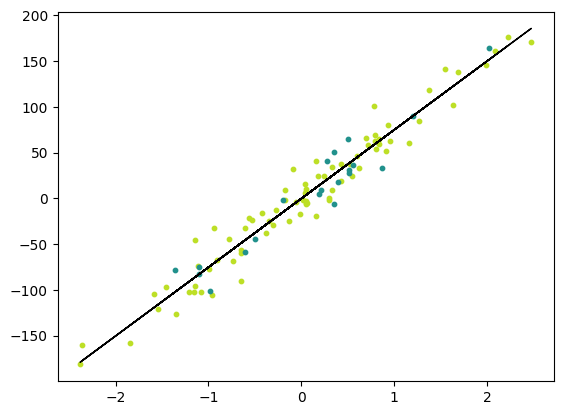

In [40]:
m1 = plt.scatter(X_train,y_train,color=cmap(0.9),s=10)
m2 = plt.scatter(X_test,y_test,color=cmap(0.5),s=10)
plt.plot(X,y_pred_line,color='black',linewidth=1,label='prediction')
plt.show()

> Done for now , good night :D